In [1]:
# basic
import os
import pickle
import warnings
import numpy as np
import pandas as pd
from tqdm import tqdm
# pre processing
from sklearn import preprocessing as pre
# NN
import torch
import torch.nn as nn
from torch import Tensor
import torch.nn.functional as F
import torch.optim as optim
from torch.nn import MSELoss
from torch_geometric.nn import GCNConv
# val and plot
#from torchmetrics.regression import R2Score
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.metrics import mean_absolute_error
from loguru import logger as log
from val import calculate_metrics
# plot
import matplotlib.pyplot as plt
# foundation model
from functools import reduce

/home/marcos/.pyenv/versions/3.10.13/envs/gnn-env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from chronos import ChronosPipeline

In [3]:
SEED = 1345
def seed_everything(seed):
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
seed_everything(SEED)
#plt.style.use('seaborn-whitegrid')
#pd.set_option('display.float_format', '{:.16f}'.format)
warnings.filterwarnings('ignore')

## Data

In [4]:
def load_datasets(filepath):
    """Carrega os datasets de arquivos pickle."""
    try:
        with open(filepath, 'rb') as f:
            dataset = pickle.load(f)
        return dataset
    except IOError as e:
        log.error(f"Erro ao carregar o dataset: {e}")
    except pickle.PickleError as e:
        log.error(f"Erro ao desserializar o dataset: {e}")
        traceback.print_exception(e)

In [5]:
fpath_root = "/mnt/data/marcos/data/node_regression_bus/data_split/"

In [6]:
os.listdir(fpath_root)

['test.pkl',
 'train.pkl',
 'val.pkl',
 'loader_03-04_2024.parquet',
 'modify',
 'loader_03-04_2024.csv']

In [7]:
test_dataset = load_datasets(f'{fpath_root}test.pkl')
# x (dados de input)
test_dataset[0].x.shape

torch.Size([2871, 280])

In [8]:
# x (dados de input)
test_dataset[0].y.shape

torch.Size([2871, 200])

In [9]:
inference_size = test_dataset[0].y.shape[1]
inference_size

200

In [10]:
nodes = [53,  365,  382,  666,  701, 1326, 1404, 1569, 1916, 2617]

In [11]:
stops = {53: '125960550',
         365: '230565994',
         382: '258781031',
         666: '43768720',
         701: '44072192',
         1326: '44783654',
         1404: '44783914',
         1569: '44784438',
         1916: '45833547',
         2617: '47568123'}

## Alterar a partir daqui

## Model

In [12]:
model_name = "chronos-t5-base"

In [13]:
pipeline = ChronosPipeline.from_pretrained(
    f"amazon/{model_name}",
    device_map="cuda",  # use "cpu" for CPU inference and "mps" for Apple Silicon
    torch_dtype=torch.bfloat16,
)

### Inference

In [14]:
scores_error = {'node': [], 'batch': [], 'mae': [], 'mse': [], 'r2': [], 'mape': []}
targets = []
cost, time = 0, 0
dfs = []


for node in nodes:
    dfs_pred = []    
    for time, snapshot in tqdm(enumerate(test_dataset)):
        snapshot.to('cpu')

        #
        # (alterar aqui o modelo)
        #
        forecast = pipeline.predict(context=torch.tensor(snapshot.x[node,:]),
                                    prediction_length=inference_size,
                                    limit_prediction_length=False,
                                    num_samples=1)
        #
        y_hat = forecast.view(-1)
        #

        # nao alterar mais abaixo
    
        cost = cost + torch.mean((y_hat-snapshot.y)**2)
        y_true = snapshot.y.cpu().data.numpy()
        y_pred = y_hat.cpu().data.numpy()
        
        scores_error['node'].append(stops[node])
        scores_error['batch'].append(time)
        scores_error['mse'].append(mean_squared_error(y_true[node,:], y_pred))
        scores_error['mae'].append(mean_absolute_error(y_true[node,:], y_pred))
        scores_error['r2'].append(r2_score(y_true[node,:], y_pred))
        scores_error['mape'].append(mean_absolute_percentage_error(y_true[node,:], y_pred))
        
        targets.append({'true': y_true,
                        'pred': y_pred})
        
        
    cost = cost / (time+1)
    cost = cost.item()
    log.info(f"node: {node} MSE test: {cost:.4f}")

0it [00:00, ?it/s]We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
1it [00:03,  3.35s/it]We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
2it [00:06,  2.98s/it]We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
3it [00:08,  2.86s/it]We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
4it [00:11,  2.81s/it]We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
5it [00:14,  2.78s/it]We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
6it [00:16,  2.76s/it]We recommend keeping prediction length <= 64. 

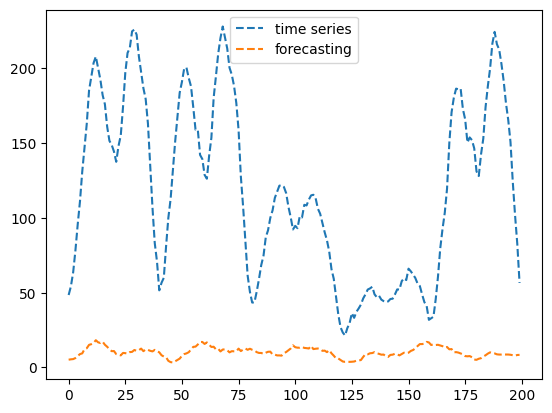

In [15]:
plt.plot(targets[10]["true"][node,:], '--', label="time series")
plt.plot(targets[10]["pred"], '--', label="forecasting")
plt.legend()
plt.show()

In [16]:
df_results = pd.DataFrame(scores_error)
df_results

,node,batch,mae,mse,r2,mape
0,125960550,0,4.893786,34.260635,-1.363099,0.456280
1,125960550,1,5.689746,49.415131,-2.631360,0.492280
2,125960550,2,4.588915,36.798656,-1.583059,0.479514
3,125960550,3,2.549778,10.909061,0.278466,0.279426
4,125960550,4,3.009852,17.143703,-0.301591,0.422918
...,...,...,...,...,...,...
375,47568123,33,52.818363,4495.251953,-0.263434,0.652210
376,47568123,34,45.027733,3968.175049,-0.036877,0.678260
377,47568123,35,82.532074,9683.943359,-2.773674,0.519554
378,47568123,36,29.083654,1734.604004,0.401300,0.286166


In [17]:
df_results["model"] = model_name
df_results.to_parquet(f"cronos-{model_name}-batch.parquet", index=False)

In [18]:
df_results

,node,batch,mae,mse,r2,mape,model
0,125960550,0,4.893786,34.260635,-1.363099,0.456280,chronos-t5-base
1,125960550,1,5.689746,49.415131,-2.631360,0.492280,chronos-t5-base
2,125960550,2,4.588915,36.798656,-1.583059,0.479514,chronos-t5-base
3,125960550,3,2.549778,10.909061,0.278466,0.279426,chronos-t5-base
4,125960550,4,3.009852,17.143703,-0.301591,0.422918,chronos-t5-base
...,...,...,...,...,...,...,...
375,47568123,33,52.818363,4495.251953,-0.263434,0.652210,chronos-t5-base
376,47568123,34,45.027733,3968.175049,-0.036877,0.678260,chronos-t5-base
377,47568123,35,82.532074,9683.943359,-2.773674,0.519554,chronos-t5-base
378,47568123,36,29.083654,1734.604004,0.401300,0.286166,chronos-t5-base


In [21]:
df_results.pivot_table(index=["model", "node"], 
                       values=["mae", "mse", "r2", "mape"], 
                       aggfunc="mean").reset_index()

,model,node,mae,mape,mse,r2
0,chronos-t5-base,125960550,5.979707,0.573860,6.086846e+01,-1.423116
1,chronos-t5-base,230565994,14.048967,1.054540,4.097949e+02,-0.620658
2,chronos-t5-base,258781031,584.180234,0.669977,5.411018e+05,-1.798836
3,chronos-t5-base,43768720,942.791856,0.780296,1.485629e+06,-1.350845
4,chronos-t5-base,44072192,66.579857,0.934560,8.257400e+03,-1.445919
5,chronos-t5-base,44783654,118.601922,0.772499,2.482109e+04,-0.722331
6,chronos-t5-base,44783914,165.739158,0.819490,5.282317e+04,-0.416913
7,chronos-t5-base,44784438,128.886779,0.824420,2.861510e+04,-0.998197
8,chronos-t5-base,45833547,44.083241,1.003325,3.324467e+03,-0.523958
9,chronos-t5-base,47568123,63.999919,0.635851,7.185421e+03,-1.240328


In [22]:
df_results.pivot_table(index=["model"], 
                       values=["mae", "mse", "r2", "mape"], 
                       aggfunc="mean").reset_index()

,model,mae,mape,mse,r2
0,chronos-t5-base,213.489164,0.806882,215222.861461,-1.05411
